### Resampling and interpolation의 흔적 감지 방법

4가지 방법으로 구성
1. ROI selection
2. signal derivative computation
3. radon transformation
4. search for periodicity

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# img = cv2.imread('human1.jpg')
# b,g,r = cv2.split(img)
# img = cv2.merge([r,g,b])
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# plt.imshow(img, cmap = 'gray')
# print(img.shape)

(5192, 5192)


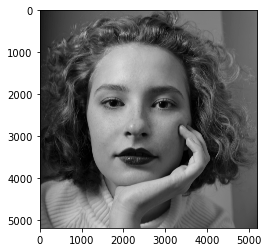

In [8]:
img = cv2.imread('human1.jpg')
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img = cv2.resize(img, dsize=(0, 0), fx=1.3, fy=1.3, interpolation=cv2.INTER_LINEAR)
print(img.shape)
plt.imshow(img, cmap='gray')

## 1. Region of Interest(ROI) selection
- typical image f(x,y); 여러개의 일관된 영역으로 구성
- 영역의 resampling 여부 조사
- R 픽셀 블록(b(x,y))으로 해당 영역 선택 (R = 128)
- 좌측상단에서 우측하단까지 수평으로 이동

In [4]:
b = []
r = 128
width, height = img.shape

for h in range(height-r):
    for w in range(width-r):
        b.append(img[w:w+r, h:h+r])  #ROI (128x128) 

In [5]:
b = np.array(b)
print(b.shape)

NameError: name 'np' is not defined

In [ ]:
plt.imshow(b[0], cmap='gray')

## 2. Signal Derivative Computation

- resampling된 이미지의 covariance(공분산) 구조; 주기적 특성을 강조하기위해 b(x,y)영역의 n차 도함수 계산
- b(x, y)의 행의 인접 픽셀간의 차이를 계산하는 도함수 연산자 사용하여 수행
- 실제 실험에서는 n = 2로 설정
    - row-based signal derivative -> sobel y축으로 2번 적용
    
<img src="https://user-images.githubusercontent.com/46768752/125272520-e8ed1700-e346-11eb-8597-1f6f8a09e889.png" width="100">

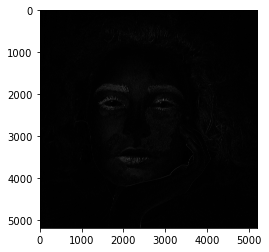

In [9]:
laplacian = cv2.Laplacian(img, cv2.CV_8U, ksize=3)

plt.imshow(laplacian, cmap='gray')

## 3. Radon Transformation


<img src="https://user-images.githubusercontent.com/46768752/125269074-526b2680-e343-11eb-874d-2bae7de9ac04.png" width="600">
<img src="https://user-images.githubusercontent.com/46768752/125269171-6a42aa80-e343-11eb-97cb-1d1beb27d1a0.png" width="800">

In [ ]:
# import scipy

# def discrete_radon_transform(image, steps):
#     R = np.zeros((steps, len(image)), dtype='float64')
#     for s in range(steps):
#         rotation = scipy.ndimage.interpolation.rotate(image, -s*180/steps).astype('float64')
#         R[:,s] = sum(rotation)
#     return R

# # Read image as 64bit float gray scale
# img = sobel_y2.astype('float64')
# radon = discrete_radon_transform(img, 220)

In [ ]:
# theta = 90
# x = 
# rotation_matrix = np.array((np.cos(theta), np.sin(theta)), (-np.sin(theta), np.cos(theta)))
# x_p, y_p = rotation_matrix.dot(x,y)

In [ ]:
from skimage.transform import radon

theta = np.linspace(0., 180., max(img.shape), endpoint=False)
sinogram = radon(img, theta=theta)
dx, dy = 0.5 * 180.0 / max(img.shape), 0.5 / sinogram.shape[0]
plt.title("Radon transform\n(Sinogram)")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.imshow(sinogram, cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
           aspect='auto')

In [ ]:
plt.imshow(sinogram, cmap='gray')

In [ ]:
plt.plot(sinogram[0])

## 4. Search for Periodicity

<img src="https://user-images.githubusercontent.com/46768752/125269975-31570580-e344-11eb-8d30-8f3463fc4329.png" width="500">

In [ ]:
p_t = sinogram[0]
m = np.mean(p_t)
r_p = []

for k in range(len(p_t)):
    sum_ = 0
    for i in range(len(p_t)):
        sum_ += (p_t[(i+k)%len(p_t)]-m)*(p_t[i]-m)
    r_p.append(sum_)

In [ ]:
plt.plot(r_p)

### 5. Fourier Transform

In [ ]:
f = np.fft.fft(r_p)
plt.plot(f)

In [ ]:
f = np.fft.fftshift(f)
plt.plot(f)